In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def switch(distr):
    if distr == "Llama 3":
        return "Llama 2"
    return "Llama 3"
def printSampledFromBook(book: str, necessary: list[str] = [], forbidden: list[str] = [], tau: float | None = None , log: bool = False):
    results_dir = Path("results")
    summary_paths = sorted(results_dir.rglob("summary.json"))

    distribution = necessary[0] if necessary else "full"
    if not summary_paths:
        print("No summary.json files found under results/")
        return
    versus = switch(forbidden[0]) if forbidden else "llama"
    plt.figure(figsize=(12, 6))
    first_time = True
    plotted_any = False
    tau_label_added = False  # <-- ensures only one legend entry

    for summary_path in summary_paths[::-1]:
        rel_parts = summary_path.relative_to(results_dir).parts
        folder_parts = rel_parts[:-1]

        if not folder_parts:
            continue

        if len(folder_parts) == 1:
            title = folder_parts[0]
        else:
            title = ", ".join(folder_parts[:0:-1]) + f" ({folder_parts[0]})"

        if book not in title:
            continue

        if "= 0" in title:
            continue
        if any(s not in title for s in necessary):
                continue
        if any(s in title for s in forbidden):
                continue    
        windows_csv = summary_path.parent / "windows.csv"
        if not windows_csv.exists():
            print(f"Missing windows.csv for: {title}")
            continue

        try:
            df = pd.read_csv(windows_csv)
        except Exception as e:
            print(f"Could not read {windows_csv}: {e}")
            continue

        required_cols = {"window_index", "p_z"}
        if not required_cols.issubset(df.columns):
            print(f"Skipping {title}: missing columns {required_cols - set(df.columns)}")
            continue

        df = df.copy()
        df["window_index"] = pd.to_numeric(df["window_index"], errors="coerce")
        df["p_z"] = pd.to_numeric(df["p_z"], errors="coerce")
        df = df.dropna(subset=["window_index", "p_z"])

        if df.empty:
            print(f"Skipping {title}: no valid data")
            continue

        df = df.sort_values("window_index")

        title_parts = title.split(", ")
        if len(title_parts) > 1:
            title = ", ".join(title_parts[1:])
        # --- main line plot ---
        plt.plot(
            df["window_index"],
            df["p_z"],
            marker="o",
            markersize=3,
            label=title
        )

        # --- highlight points below tau (only if tau is provided) ---
        # --- tau behavior ---
        if tau is not None and first_time:
            if log:
                # draw horizontal line instead of highlighting points
                plt.axhline(
                y=tau,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label=f"threshold τ = {tau}"
                )
                first_time = False
            else:
                # original behavior: highlight points below tau
                below_tau = df[df["p_z"] < tau]
                if not below_tau.empty:
                    plt.scatter(
                    below_tau["window_index"],
                    below_tau["p_z"],
                    facecolors="none",
                    edgecolors="red",
                    s=60,
                    linewidths=1.5,
                    label=(
                    f"points below threshold τ = {tau}"
                    if not tau_label_added else None
                    )
                    )
                    tau_label_added = True

        plotted_any = True

    if not plotted_any:
        print(f"No matching data found for book: {book}")
        plt.close()
        return

    plt.xlabel("window_index")
    plt.ylabel("p_z")
    ptitle = f"{versus} to LLaDA comparison on {book} with {distribution} distribution"
    if(log):
        ptitle += ", log-plot"
    plt.title(ptitle)
    plt.grid(True, linestyle="--", alpha=0.5)
    
    if log:
        plt.yscale("log")  # log scale on y-axis
        # optionally:
        # plt.xscale("log")  # uncomment if you also want x-axis log

    plt.legend(fontsize=8)
    plt.tight_layout()

    
    # --- save figure ---
    output_path = Path("plots")
    output_path.mkdir(exist_ok=True)
    
    filename =  f"{book}_{distribution}_{versus}_{'log' if log else 'linear'}.png".replace(" ", "_")
    plt.savefig(output_path / (filename), dpi=300, bbox_inches="tight")
    
    plt.show()

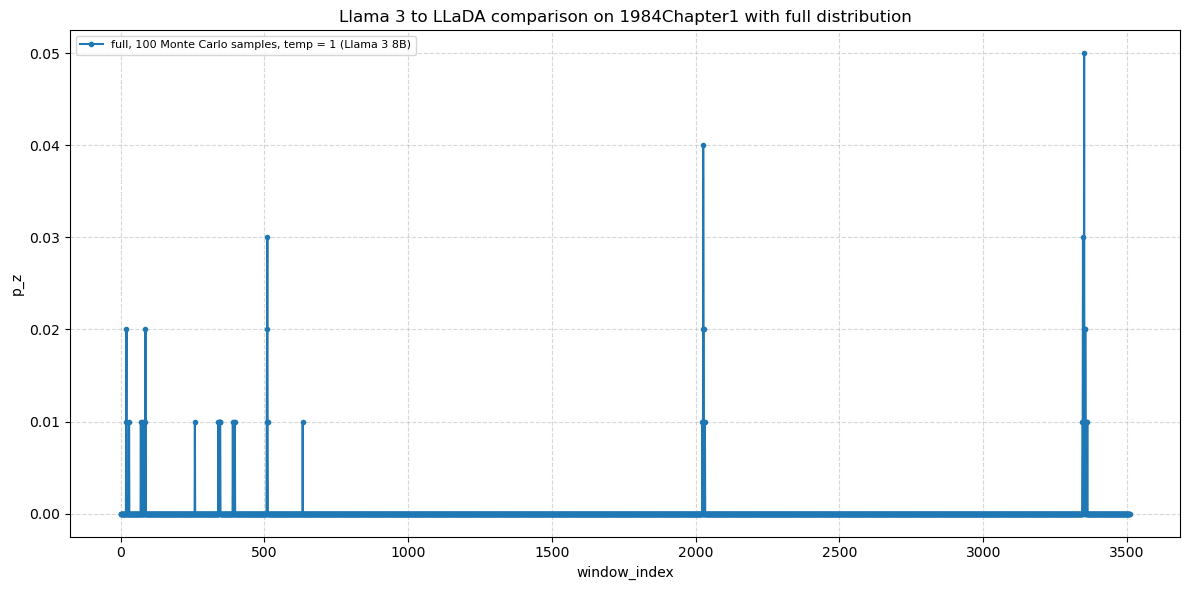

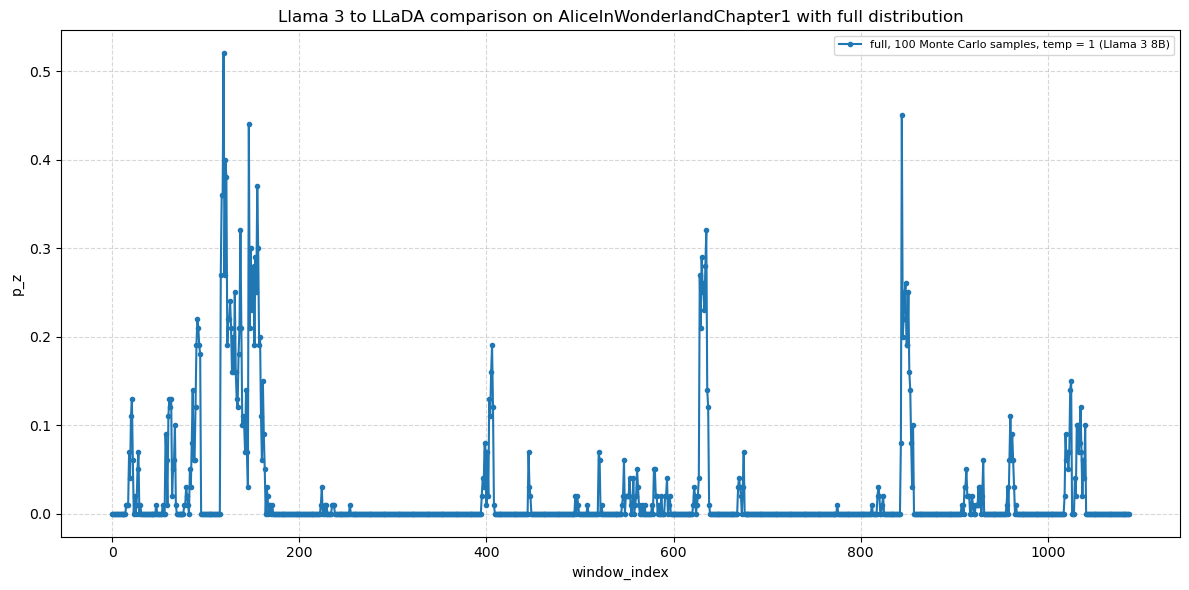

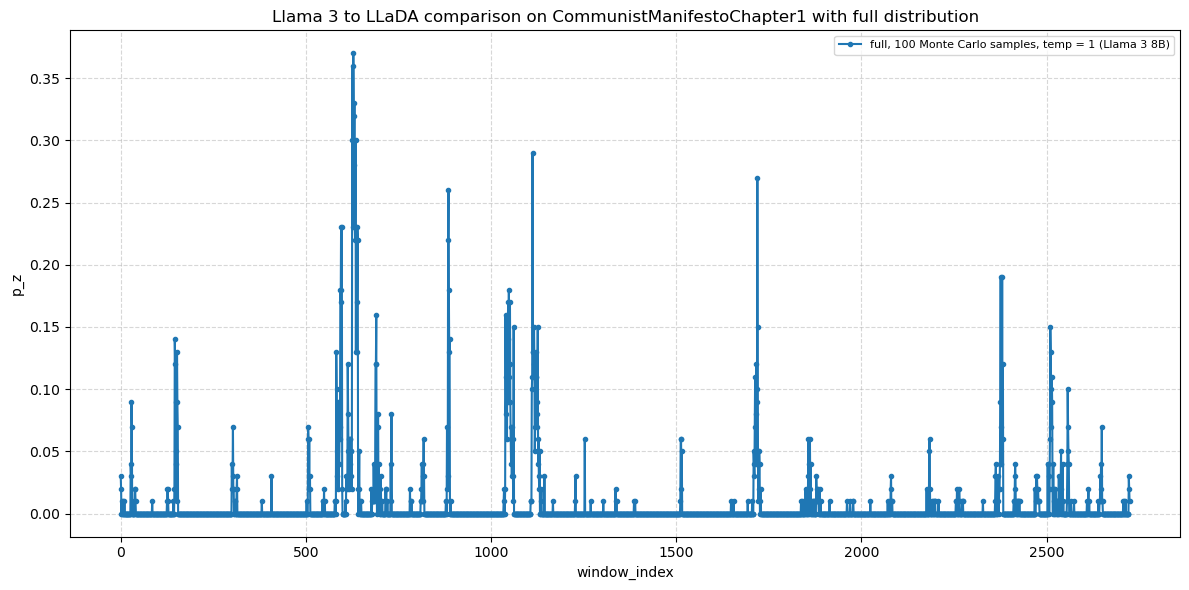

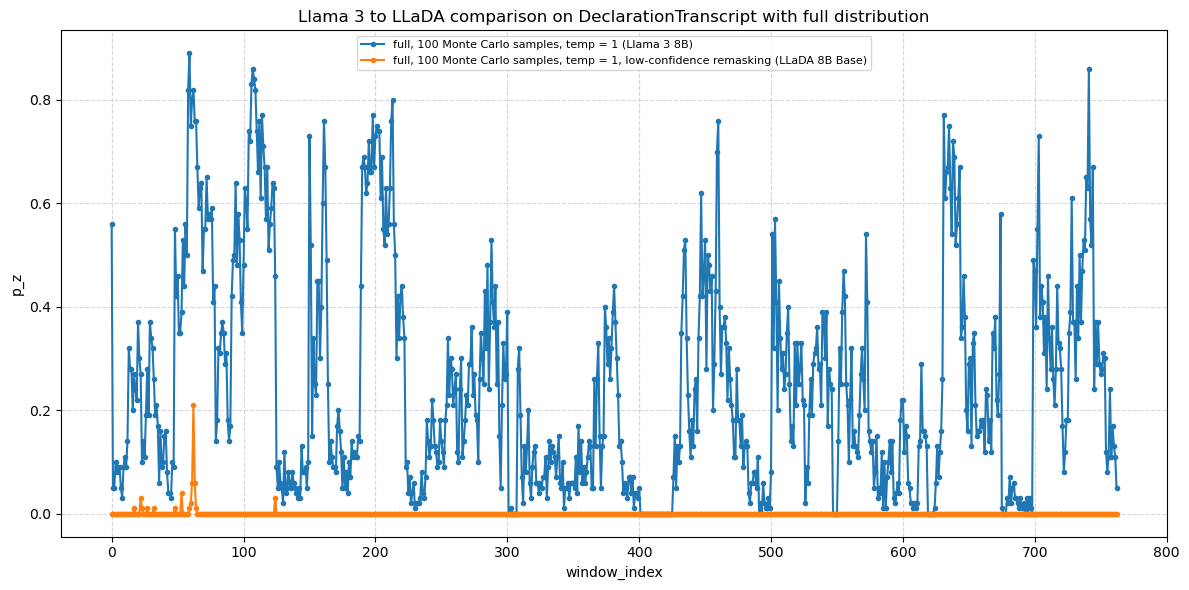

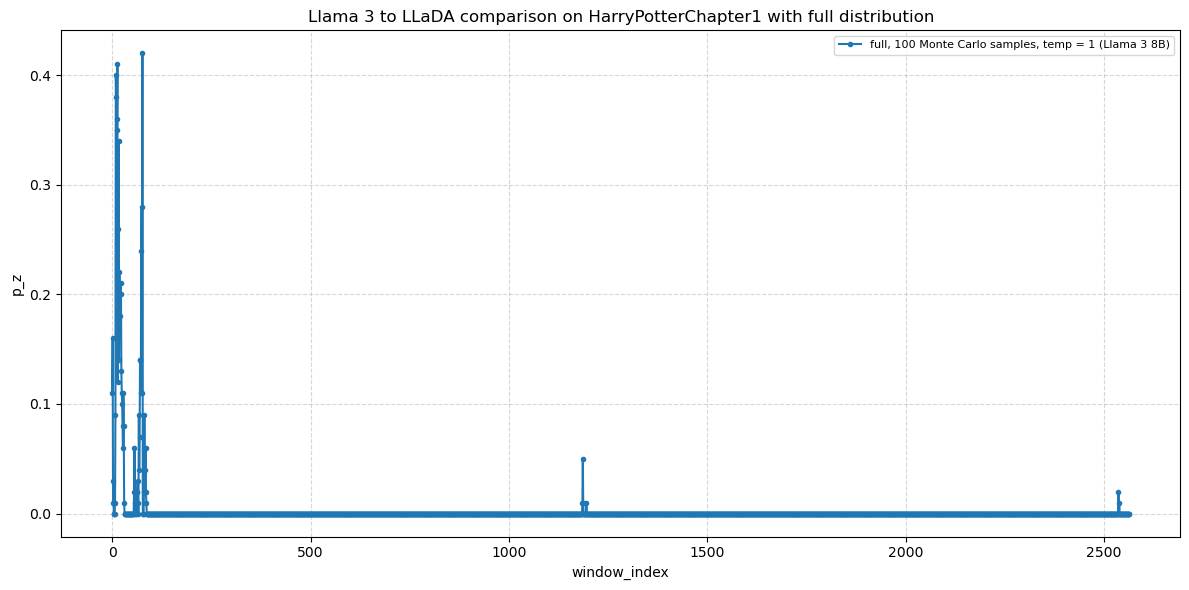

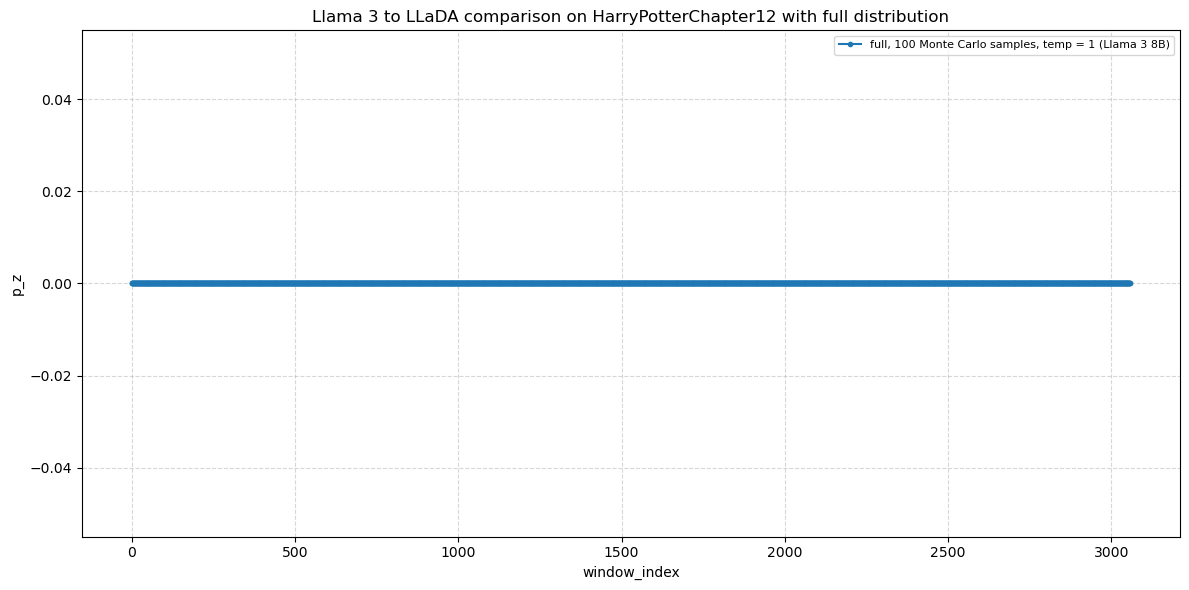

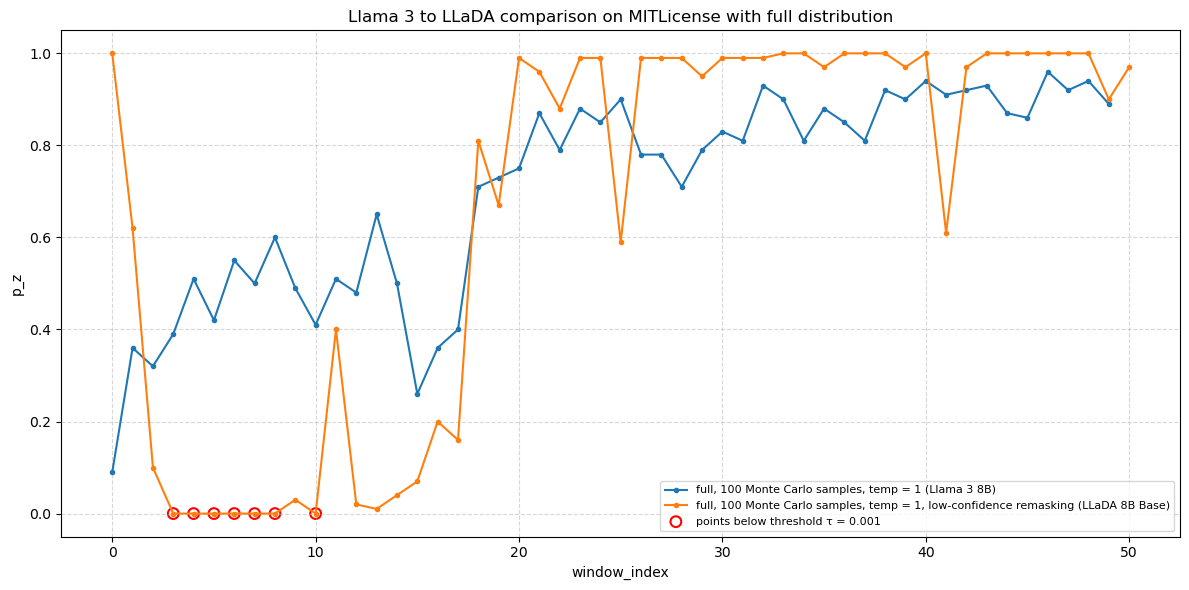

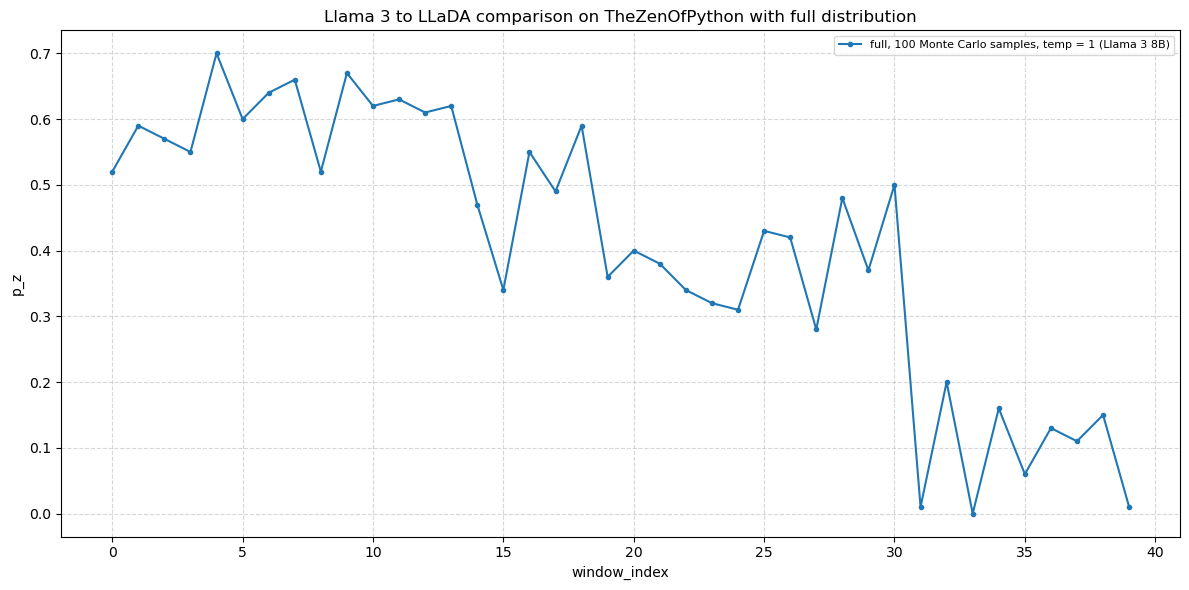

In [7]:
texts = ["1984Chapter1", "AliceInWonderlandChapter1", "CommunistManifestoChapter1", "DeclarationTranscript", "HarryPotterChapter1", "HarryPotterChapter12", "MITLicense", "TheZenOfPython"]
for text in texts:
    tau = None
    prohibido =["Llama 2"] 
    if text == "HarryPotterChapter1":
        prohibido.append("12")
    if "hapter" in text or "Python" in text:
        prohibido.append("8B Base")
    if "MIT" in text:
        tau = 0.001
    printSampledFromBook(text,forbidden = prohibido ,necessary = ["full", "Monte Carlo"], tau = tau)

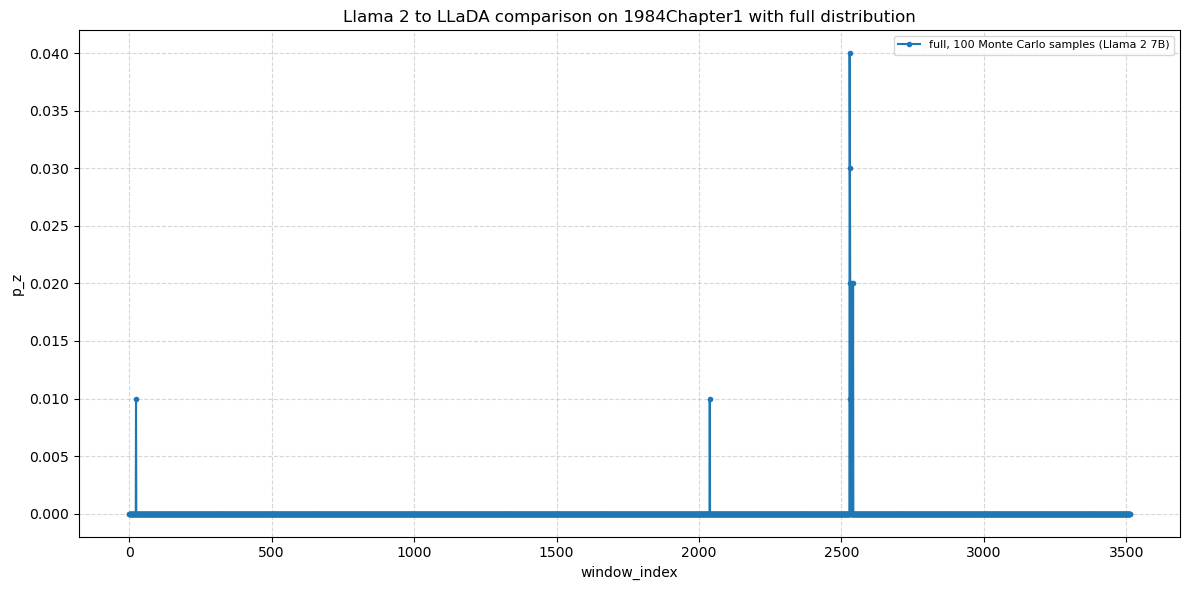

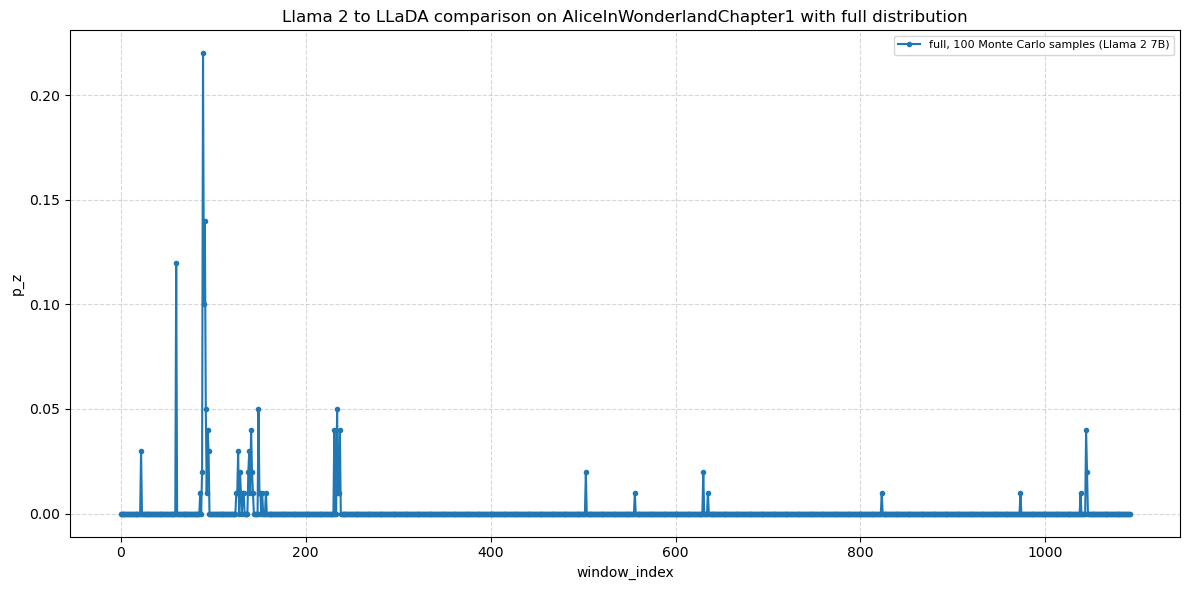

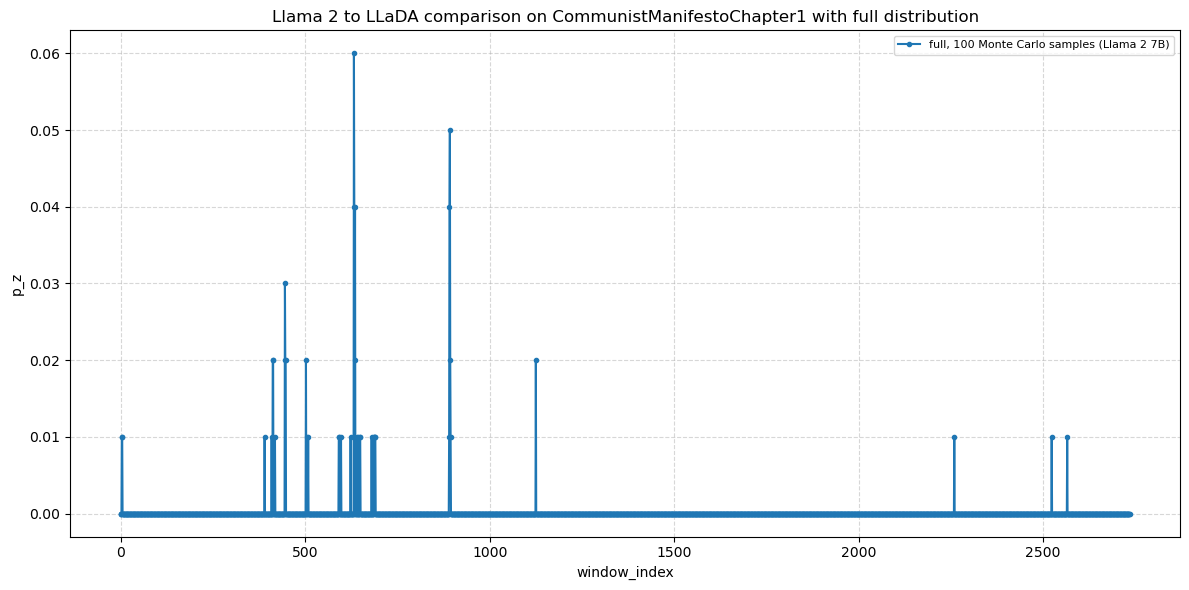

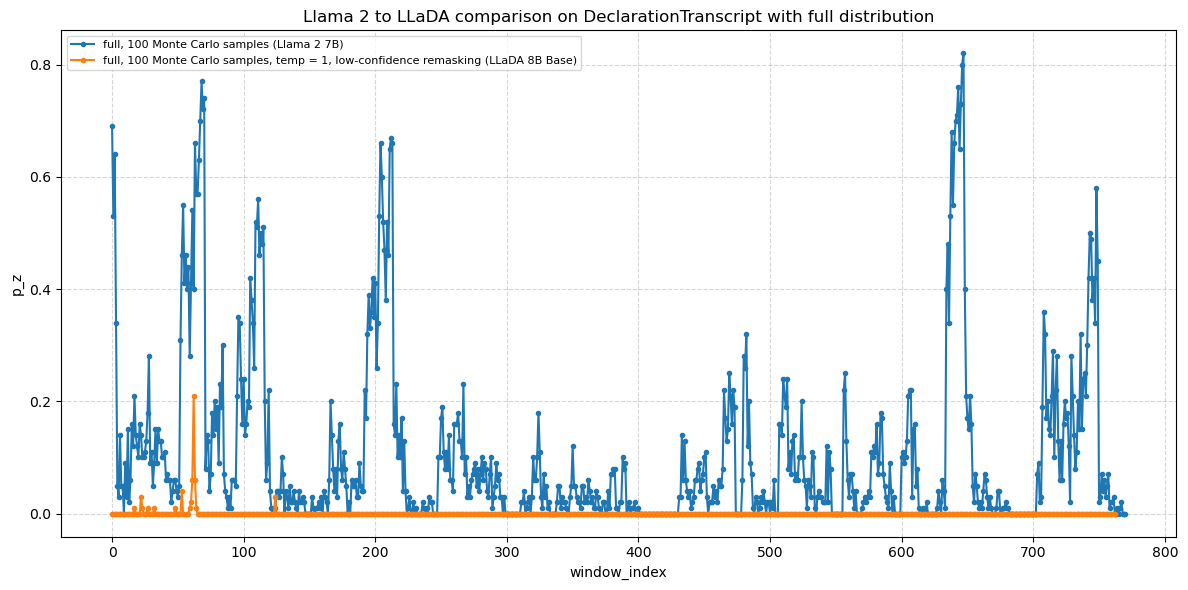

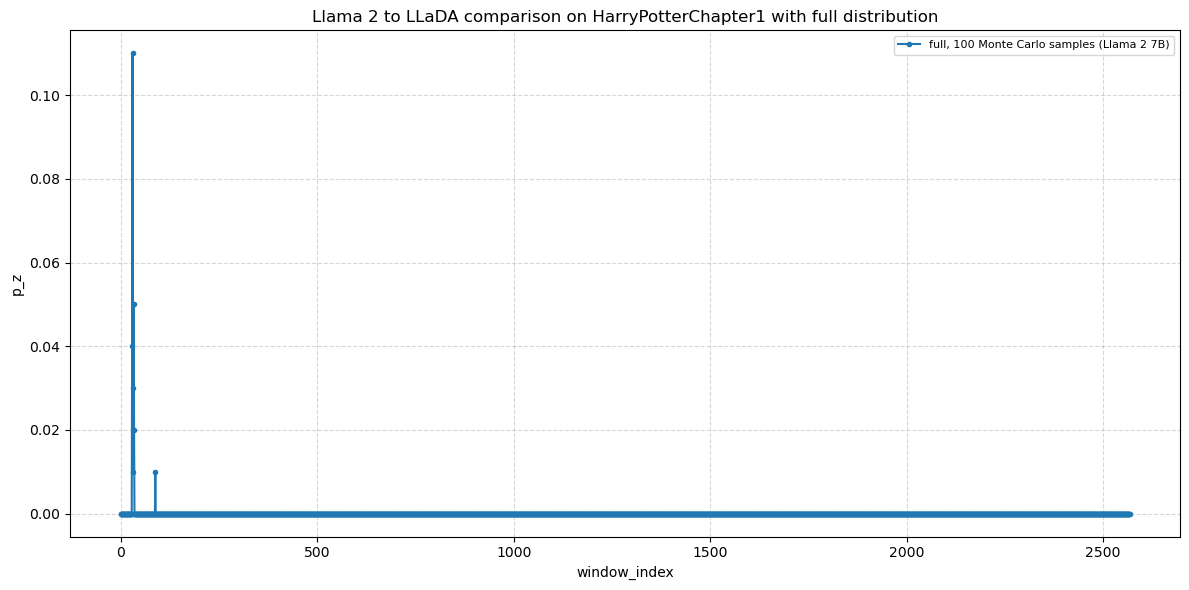

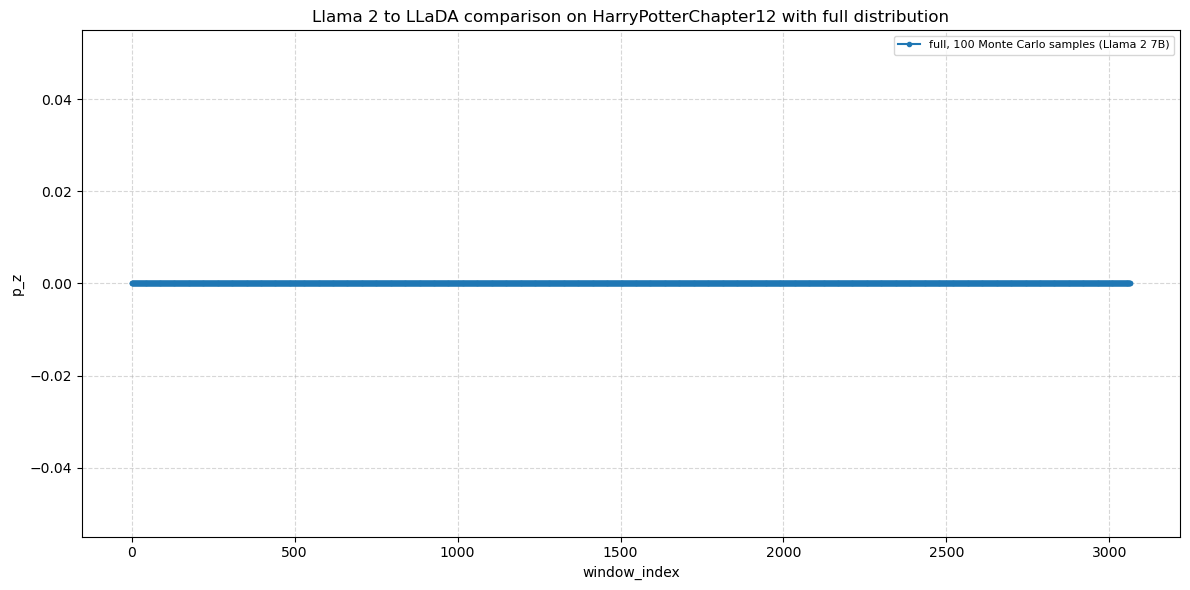

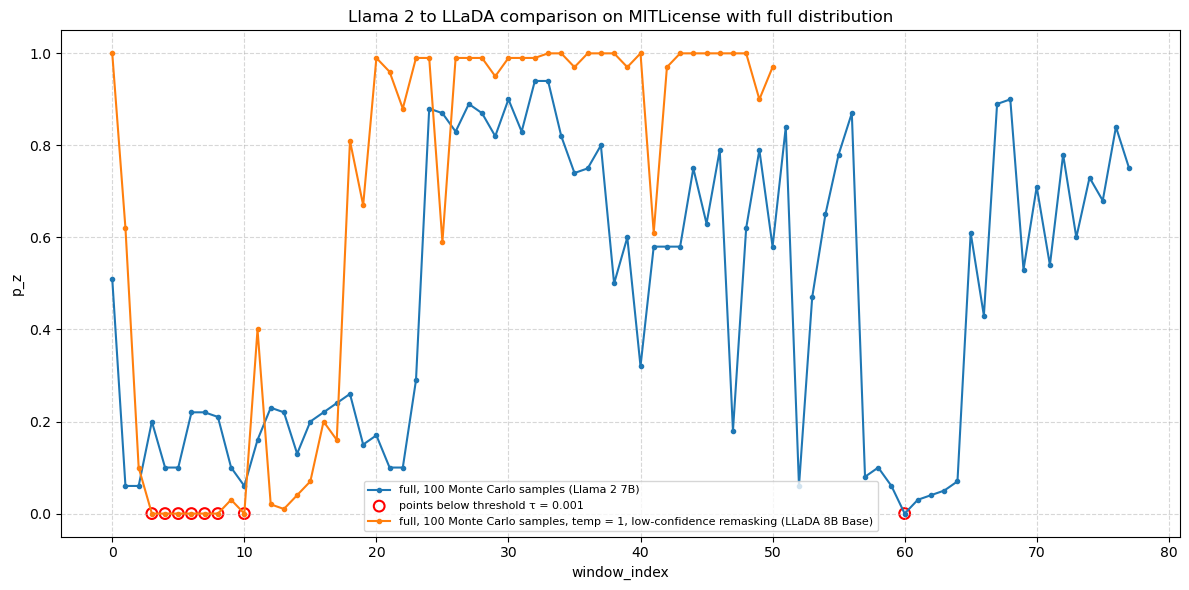

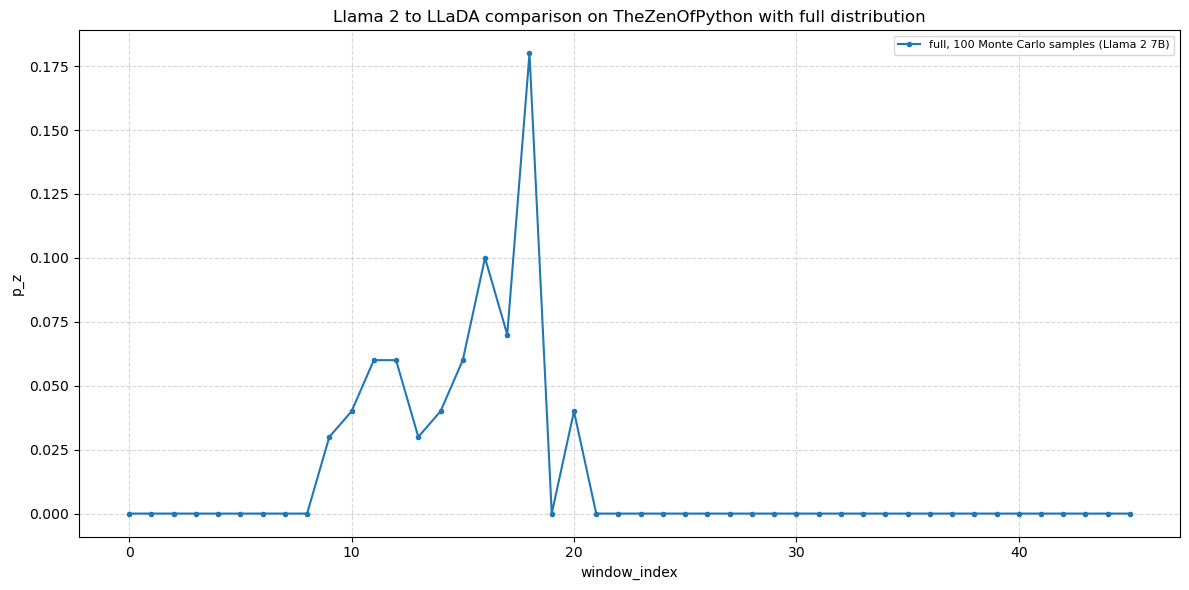

In [9]:
texts = ["1984Chapter1", "AliceInWonderlandChapter1", "CommunistManifestoChapter1", "DeclarationTranscript", "HarryPotterChapter1", "HarryPotterChapter12", "MITLicense", "TheZenOfPython"]
for text in texts:
    tau = None
    prohibido =["Llama 3"] 
    if text == "HarryPotterChapter1":
        prohibido.append("12")
    if "hapter" in text or "Python" in text:
        prohibido.append("8B Base")
    if "MIT" in text:
        tau = 0.001
    printSampledFromBook(text,forbidden = prohibido ,necessary = ["full", "Monte Carlo"],tau = tau)

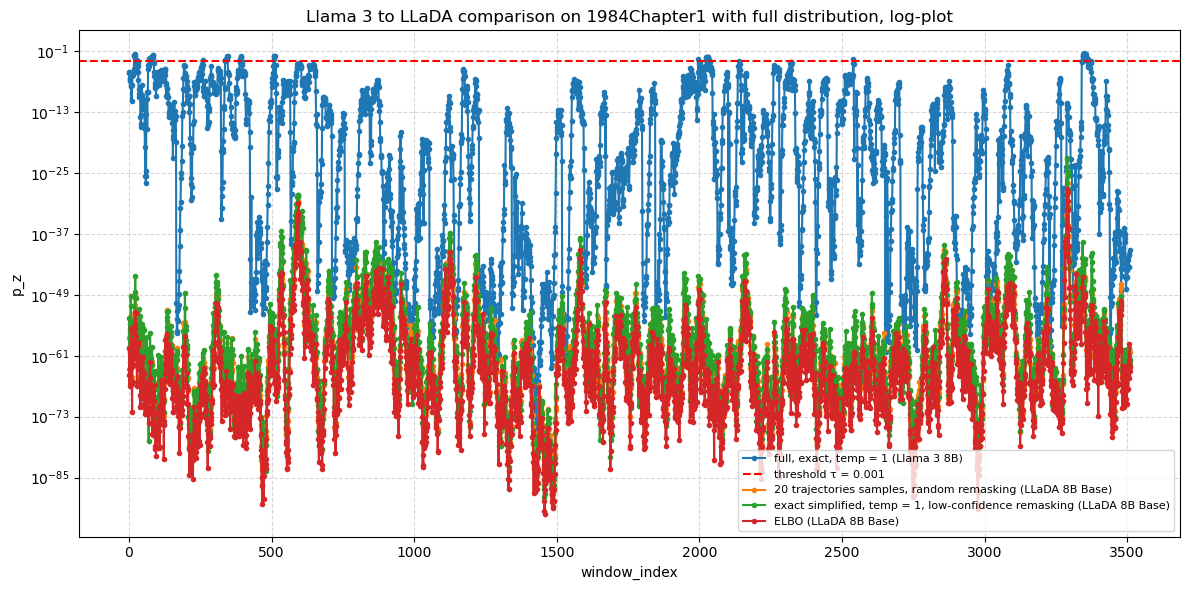

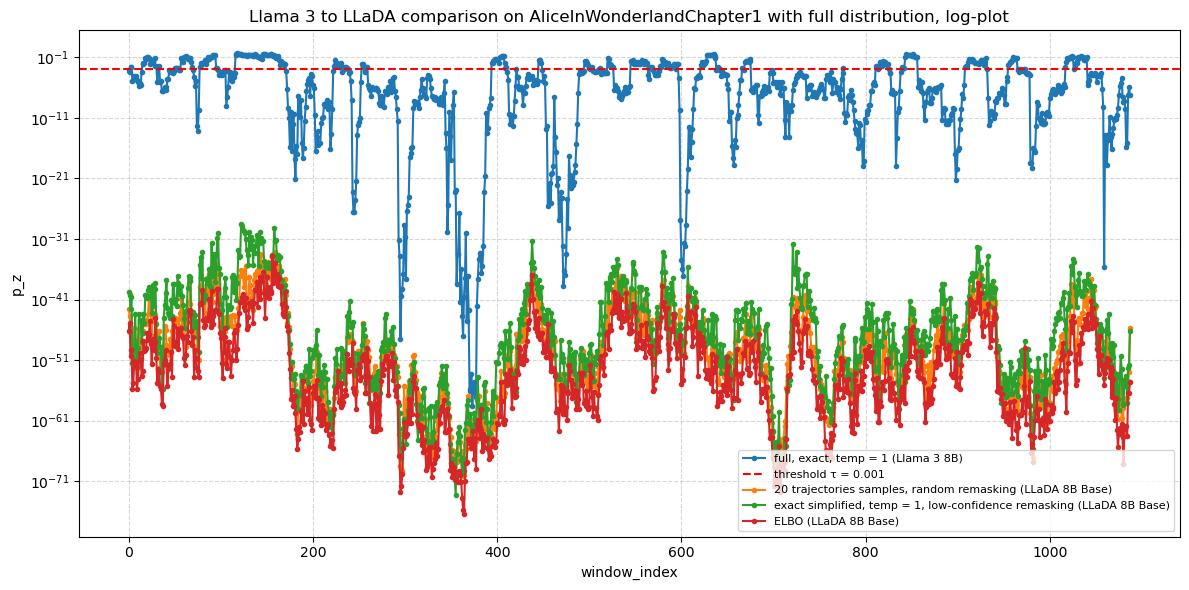

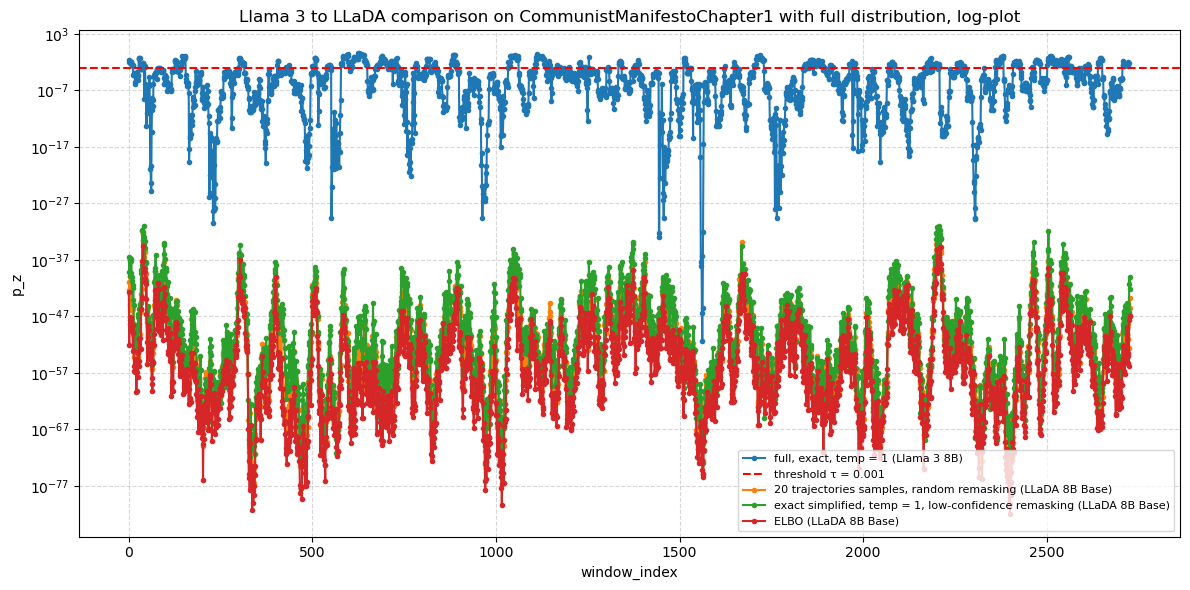

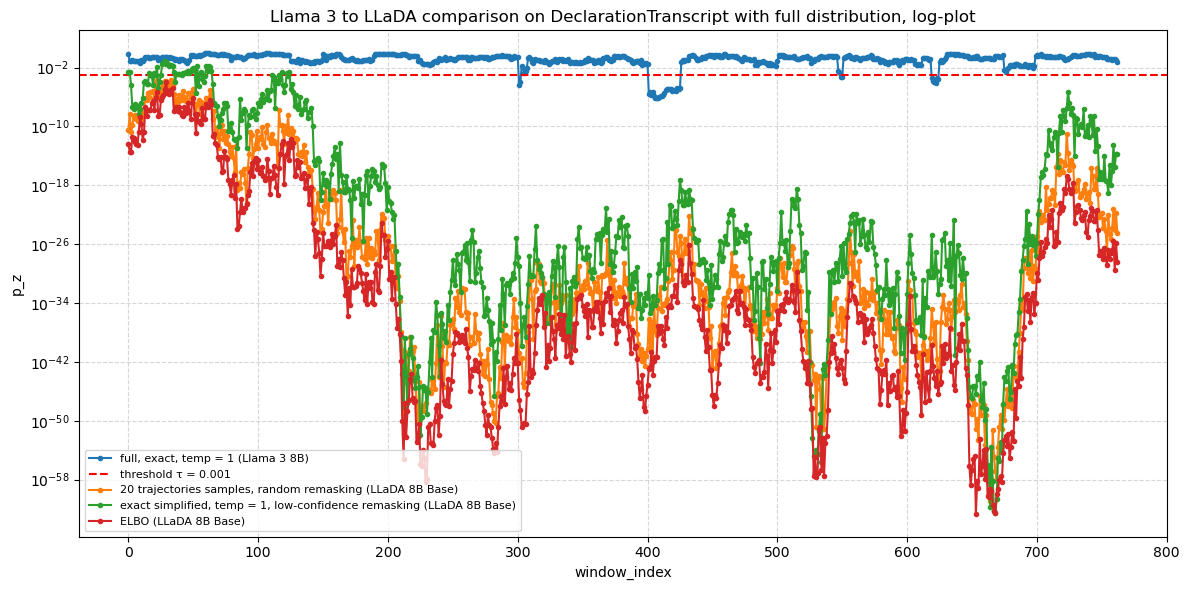

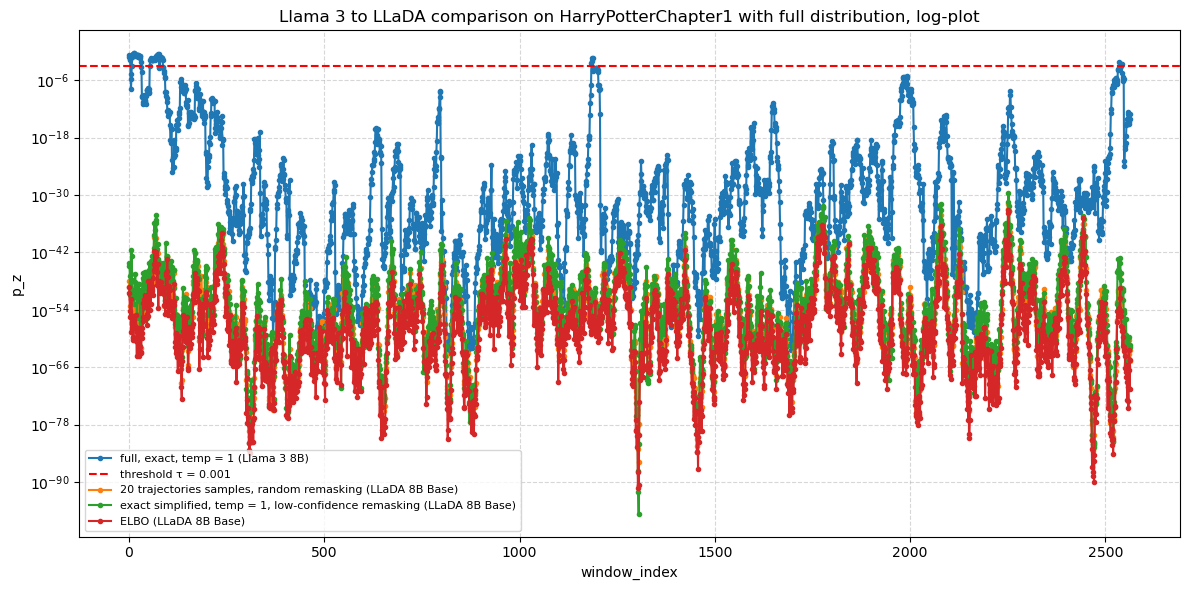

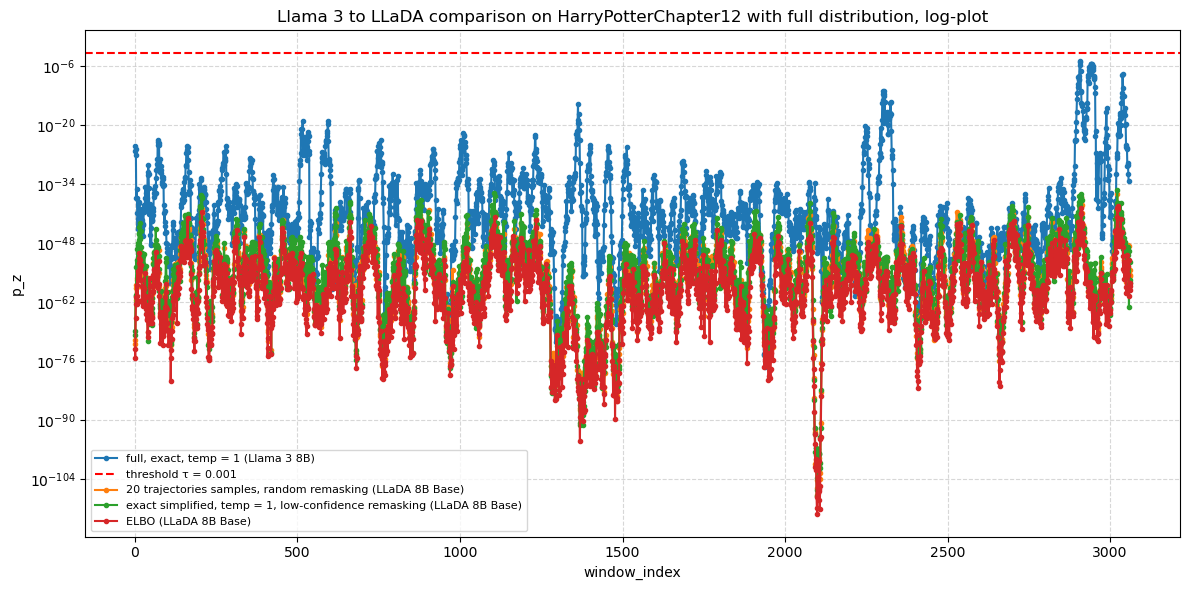

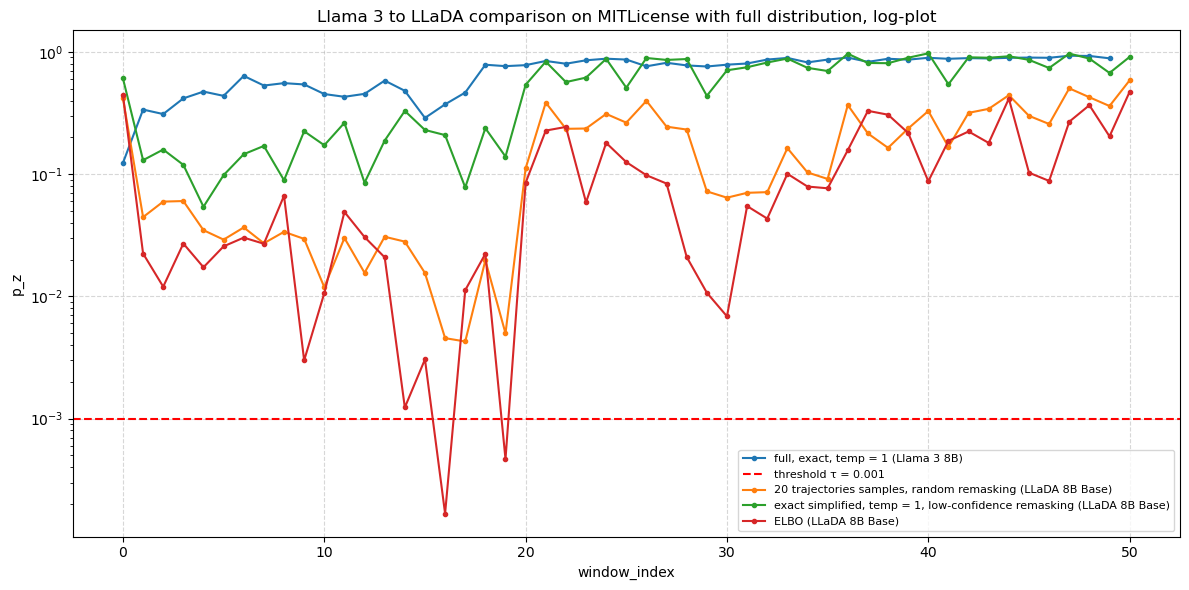

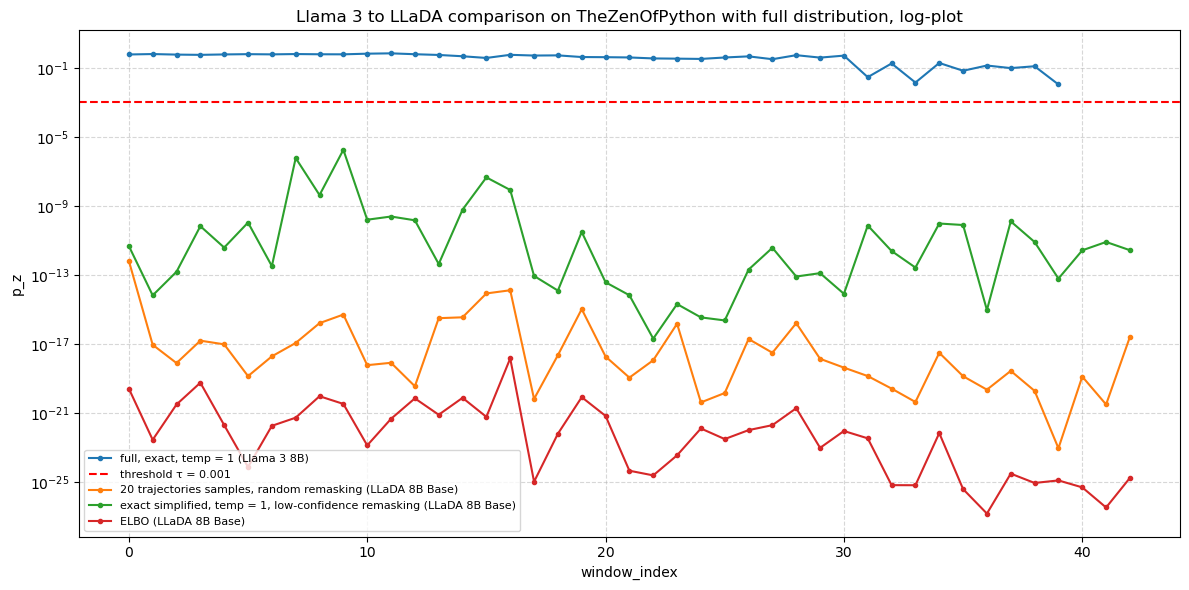

In [4]:
texts = ["1984Chapter1", "AliceInWonderlandChapter1", "CommunistManifestoChapter1", "DeclarationTranscript", "HarryPotterChapter1", "HarryPotterChapter12", "MITLicense", "TheZenOfPython"]
for text in texts:
    prohibido =["Llama 2", "Monte Carlo", "top_k"] 
    if text == "HarryPotterChapter1":
        prohibido.append("12")
        
    printSampledFromBook(text,forbidden = prohibido ,necessary = [], log = True, tau = 0.001)

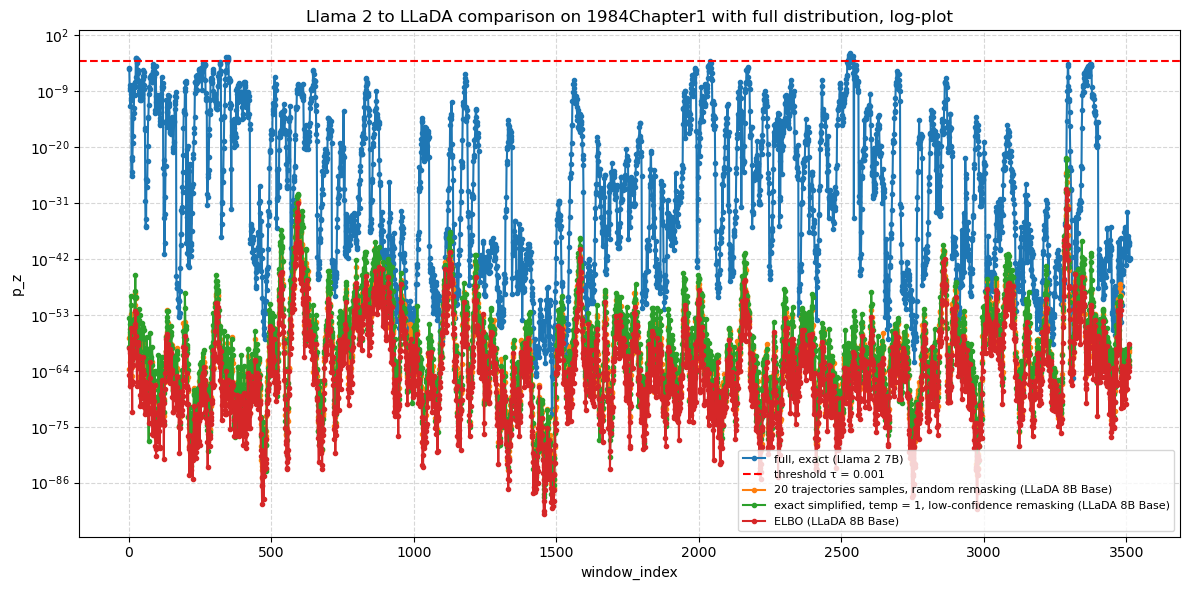

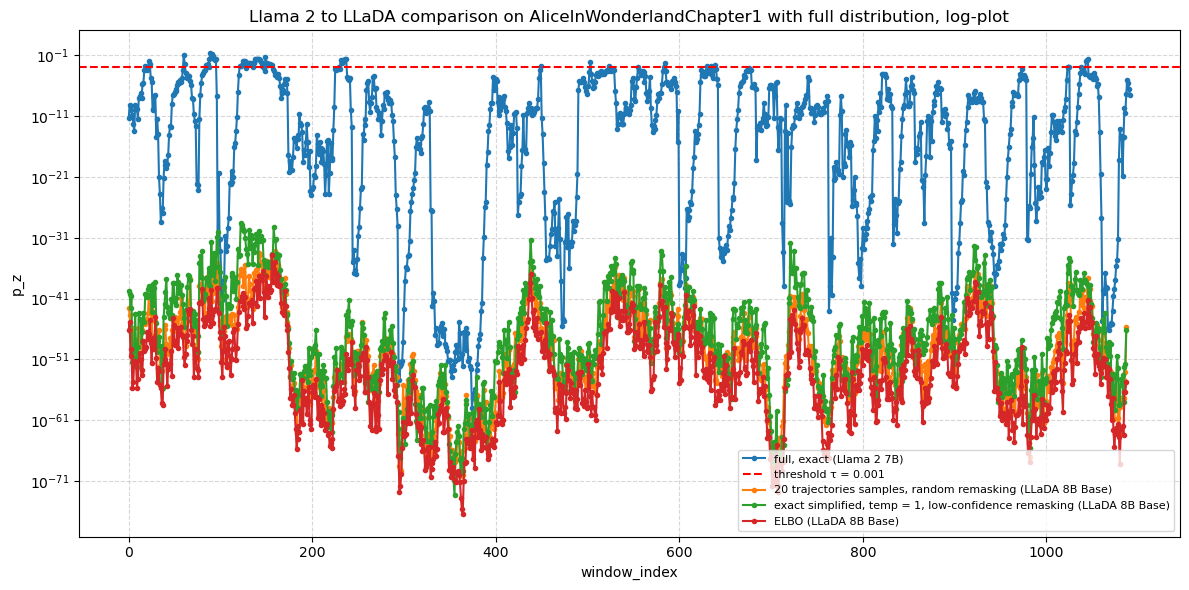

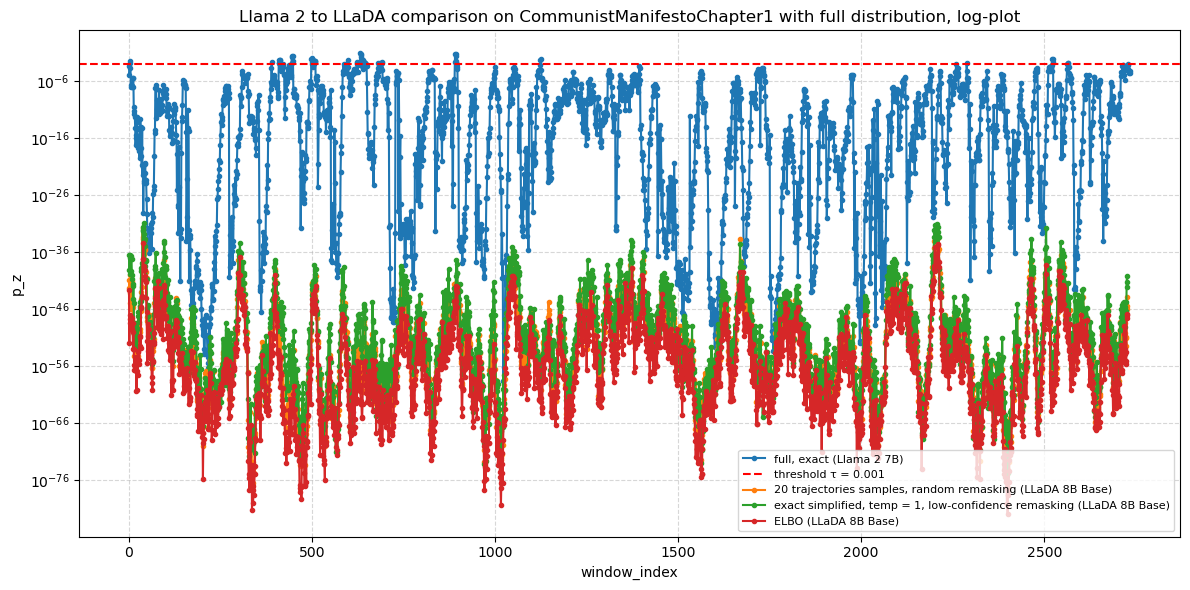

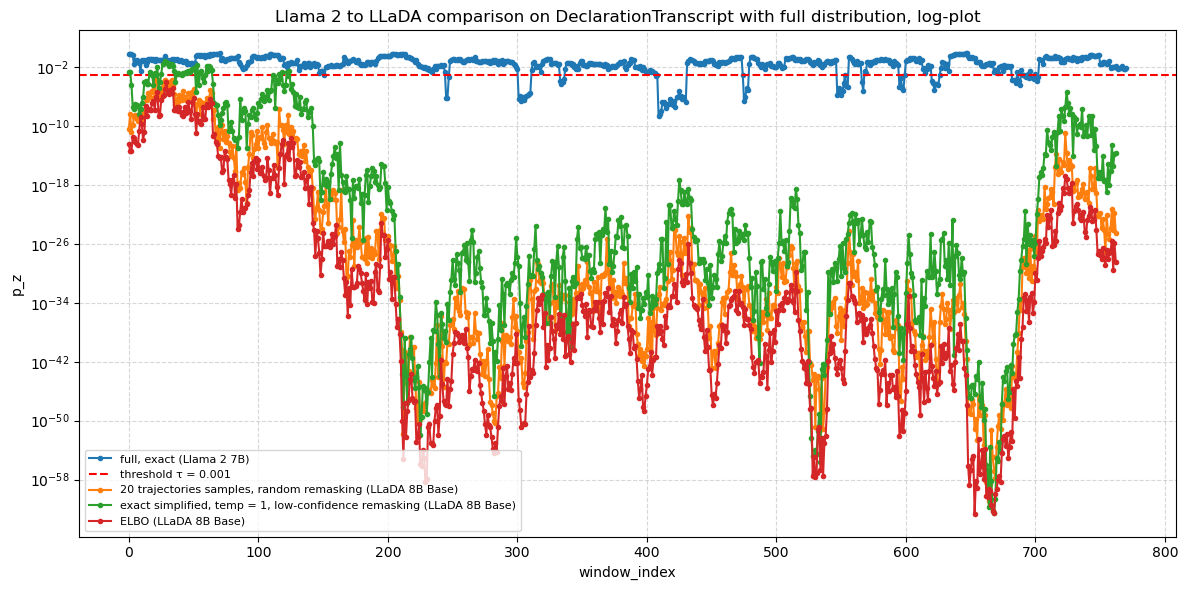

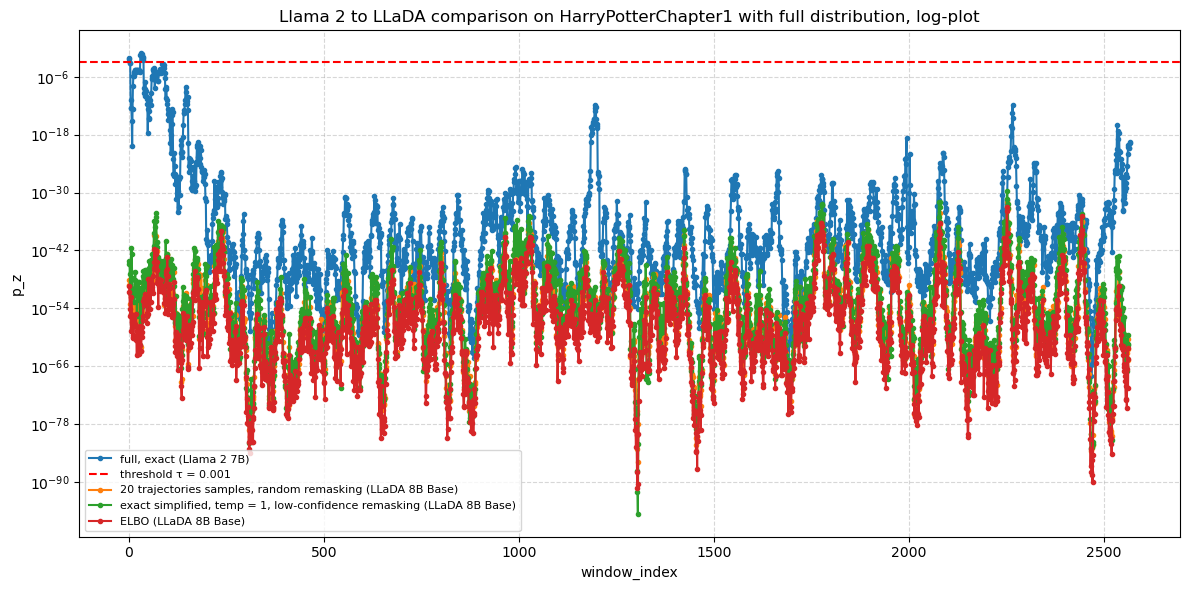

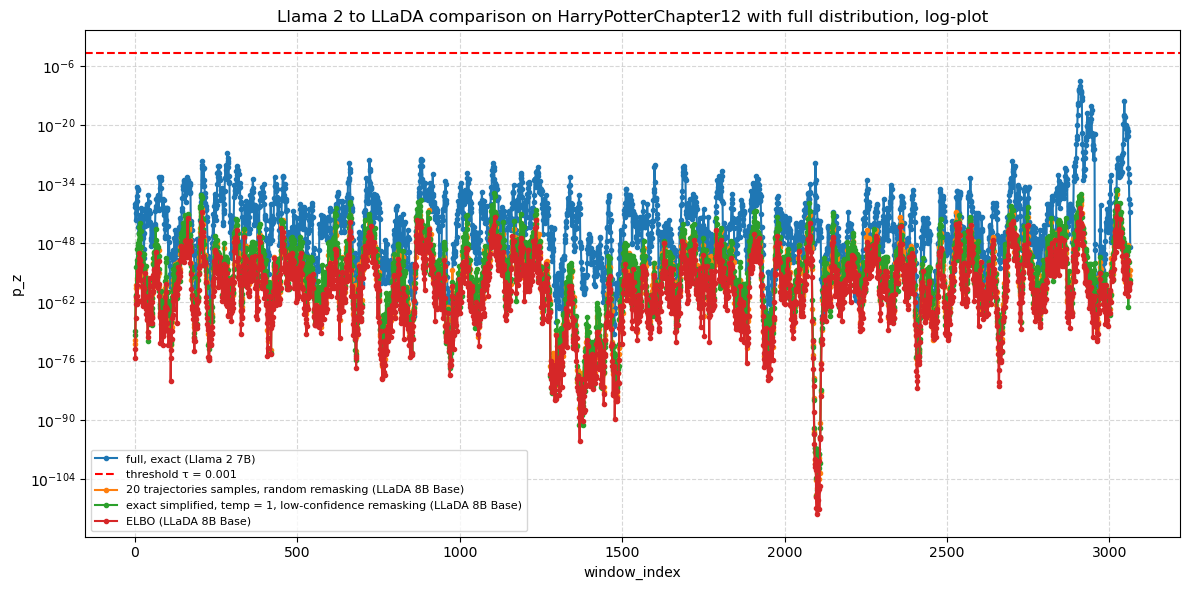

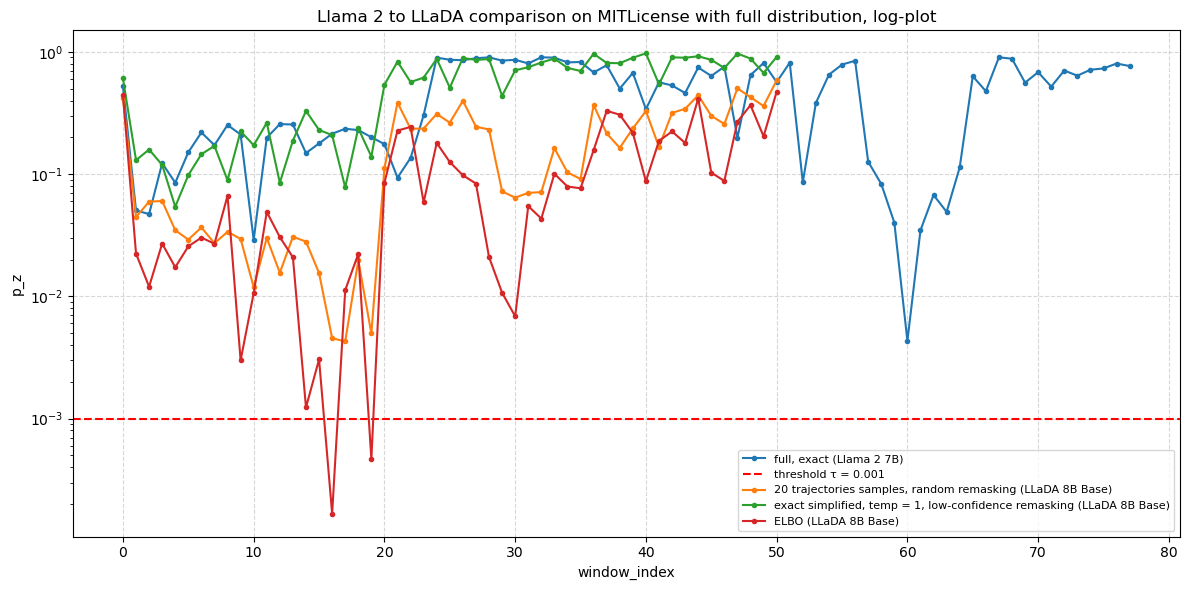

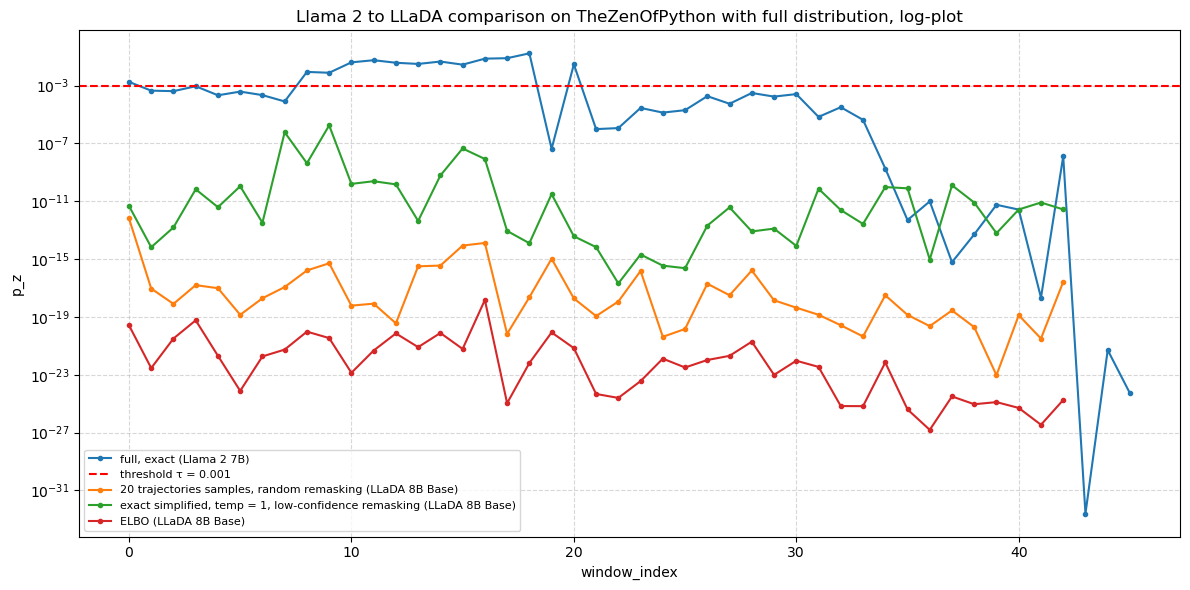

In [5]:
texts = ["1984Chapter1", "AliceInWonderlandChapter1", "CommunistManifestoChapter1", "DeclarationTranscript", "HarryPotterChapter1", "HarryPotterChapter12", "MITLicense", "TheZenOfPython"]
for text in texts:
    prohibido =["Llama 3", "Monte Carlo", "top_k"] 
    if text == "HarryPotterChapter1":
        prohibido.append("12")
        
    printSampledFromBook(text,forbidden = prohibido ,necessary = [], log = True, tau = 0.001)

In [6]:
from pathlib import Path
import json

# Your notebook is one level above "results"
RESULTS_DIR = Path("results")

def dfs_print_summaries(folder: Path, prefix_parts=None):
    if prefix_parts is None:
        prefix_parts = []

    # Sort so traversal order is stable
    subdirs = sorted([p for p in folder.iterdir() if p.is_dir()], key=lambda p: p.name)

    # If this folder itself contains summary.json, print it
    summary_file = folder / "summary.json"
    if summary_file.exists():
        try:
            with summary_file.open("r", encoding="utf-8") as f:
                data = json.load(f)

            extraction_rate = data.get("extraction_rate")
            if extraction_rate is not None:
                label = " ".join(prefix_parts) if prefix_parts else folder.name
                print(f"{label} : {extraction_rate * 100:.1f}%")
        except Exception as e:
            print(f"Error reading {summary_file}: {e}")

    # Then recurse into subfolders (DFS)
    for subdir in subdirs:
        dfs_print_summaries(subdir, prefix_parts + [subdir.name])

# Run
dfs_print_summaries(RESULTS_DIR, [])

LLaDA 8B Base ELBO 1984Chapter1 : 0.0%
LLaDA 8B Base ELBO AliceInWonderlandChapter1 : 0.0%
LLaDA 8B Base ELBO AssassinationAliKhamenei : 0.0%
LLaDA 8B Base ELBO CommunistManifestoChapter1 : 0.0%
LLaDA 8B Base ELBO DeclarationTranscript : 0.0%
LLaDA 8B Base ELBO HarryPotterChapter1 : 0.0%
LLaDA 8B Base ELBO HarryPotterChapter12 : 0.0%
LLaDA 8B Base ELBO MITLicense : 96.1%
LLaDA 8B Base ELBO TheRaven : 0.0%
LLaDA 8B Base ELBO TheZenOfPython : 0.0%
LLaDA 8B Base low-confidence remasking temp = 0 AssassinationAliKhamenei 50+5 : 3.8%
LLaDA 8B Base low-confidence remasking temp = 0 AssassinationAliKhamenei 50+50 : 0.0%
LLaDA 8B Base low-confidence remasking temp = 0 DeclarationTranscript 50+5 : 16.0%
LLaDA 8B Base low-confidence remasking temp = 0 DeclarationTranscript 50+50 : 0.1%
LLaDA 8B Base low-confidence remasking temp = 1 100 Monte Carlo samples full AliceInWonderlandChapter1 : 0.0%
LLaDA 8B Base low-confidence remasking temp = 1 100 Monte Carlo samples full AssassinationAliKhamenei :